# Set up workspace

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import warnings
import sys
from sklearn.linear_model import LinearRegression

In [2]:
warnings.filterwarnings('ignore')

sys.path.append('/glade/u/home/czarakas/coupled_PPE/code/utils/')

In [3]:
from load_ensembles import *
import quick_map
from plotting_settings import *
from load_gridcell_areas import *

In [4]:
sys.path.append('/glade/u/home/czarakas/coupled_PPE/code/06_analyze_simulations/generate_figures/')
from calculate_annual_means import *

# Load all data

In [5]:
dir_input='/glade/work/czarakas/coupled_PPE/data/data_for_figures/annual_means/'

In [6]:
#deltas
delta_Ts=xr.open_dataset(dir_input+'delta_TSKIN_Annual_mean_coupled.nc')['TSKIN']
PRECT=xr.open_dataset(dir_input+'delta_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')

In [7]:
#Reference annual time series
Ts_offline_ref=xr.open_dataset(dir_input+'ref_TSKIN_Annual_mean_offline.nc')['TSKIN']
FSDS_offline_ref=xr.open_dataset(dir_input+'ref_FSDS_Annual_mean_offline.nc')['FSDS']
FSR_offline_ref=xr.open_dataset(dir_input+'ref_FSR_Annual_mean_offline.nc')['FSR']
LH_offline_ref=xr.open_dataset(dir_input+'ref_EFLX_LH_TOT_Annual_mean_offline.nc')['EFLX_LH_TOT']
SH_offline_ref=xr.open_dataset(dir_input+'ref_FSH_Annual_mean_offline.nc')['FSH']
Ts_coupled_ref=xr.open_dataset(dir_input+'ref_TSKIN_Annual_mean_coupled.nc')['TSKIN']

In [8]:
#Absolute values of variables
da_Ts_coupled=xr.open_dataset(dir_input+'TSKIN_Annual_mean_coupled.nc')['TSKIN']
da_Ts_offline=xr.open_dataset(dir_input+'TSKIN_Annual_mean_offline.nc')['TSKIN']
da_FSDS_offline=xr.open_dataset(dir_input+'FSDS_Annual_mean_offline.nc')['FSDS']
da_FSR_offline=xr.open_dataset(dir_input+'FSR_Annual_mean_offline.nc')['FSR']
da_LH_offline=xr.open_dataset(dir_input+'EFLX_LH_TOT_Annual_mean_offline.nc')['EFLX_LH_TOT']
da_SH_offline=xr.open_dataset(dir_input+'FSH_Annual_mean_offline.nc')['FSH']

#FSDS=xr.open_dataset(dir_input+'FSDS_Annual_mean_offline.nc')['FSDS']
#FSR=xr.open_dataset(dir_input+'FSR_Annual_mean_offline.nc')['FSR']
#LH=xr.open_dataset(dir_input+'EFLX_LH_TOT_Annual_mean_offline.nc')['EFLX_LH_TOT']
#SH=xr.open_dataset(dir_input+'FSH_Annual_mean_offline.nc')['FSH']

In [9]:
dir_input='/glade/work/czarakas/coupled_PPE/data/data_for_figures/land_surface_properties/'
deltas_ra_offline=xr.open_dataset(dir_input+'delta_ra.nc')['__xarray_dataarray_variable__']

In [10]:
dir_input2='/glade/campaign/cgd/tss/czarakas/CoupledPPE/offline_simulations/'

basecase_lnd_offline_Ts=xr.open_dataset(dir_input2+'OFFL0000_PI_v02/lnd/proc/tseries/OFFL0000_PI_v02.clm2.h0.timeseries.'+'TSKIN'+'.nc')
basecase_lnd_offline_FSDS=xr.open_dataset(dir_input2+'OFFL0000_PI_v02/lnd/proc/tseries/OFFL0000_PI_v02.clm2.h0.timeseries.'+'FSDS'+'.nc')
basecase_lnd_offline_FSA=xr.open_dataset(dir_input2+'OFFL0000_PI_v02/lnd/proc/tseries/OFFL0000_PI_v02.clm2.h0.timeseries.'+'FSA'+'.nc')
basecase_lnd_offline_LH=xr.open_dataset(dir_input2+'OFFL0000_PI_v02/lnd/proc/tseries/OFFL0000_PI_v02.clm2.h0.timeseries.'+'EFLX_LH_TOT'+'.nc')
basecase_lnd_offline_SH=xr.open_dataset(dir_input2+'OFFL0000_PI_v02/lnd/proc/tseries/OFFL0000_PI_v02.clm2.h0.timeseries.'+'FSH'+'.nc')

In [11]:
basecase_lnd_coupled_Ts=xr.open_dataset('/glade/campaign/cgd/tss/czarakas/CoupledPPE/coupled_simulations/COUP0000_PI_SOM/lnd/proc/tseries/COUP0000_PI_SOM.clm2.h0.timeseries.'+'TSKIN'+'.nc')

In [12]:
#crosswalk = pd.read_csv('/glade/u/home/czarakas/coupled_PPE/code/02_set_up_ensemble/CLM5PPE_coupledPPE_crosswalk.csv')
#keys_short=crosswalk.key_coupledPPE.str.split('COUP', expand=True)[1]
#crosswalk['Key_short']=keys_short
#crosswalk['description']=crosswalk['param']+', '+crosswalk['minmax']
#crosswalk=crosswalk.drop(index=0)

#keys=crosswalk['Key_short'].values
#keys_coupledPPE = crosswalk['key_coupledPPE'].values
#keys_landonlyPPE = crosswalk['key_landonlyPPE'].values

# Global mean analysis

In [13]:
delta_ra_global=(deltas_ra_offline*landweights2).sum(dim=['lat','lon'])

In [14]:
LH_global=(da_LH_offline*landweights2).sum(dim=['lat','lon'])
SH_global=(da_SH_offline*landweights2).sum(dim=['lat','lon'])
LH_global_ref=(LH_offline_ref*landweights2).sum(dim=['lat','lon'])
SH_global_ref=(SH_offline_ref*landweights2).sum(dim=['lat','lon'])

FSR_global=(da_FSR_offline*landweights2).sum(dim=['lat','lon'])
FSDS_global=(da_FSDS_offline*landweights2).sum(dim=['lat','lon'])
FSR_global_ref=(FSR_offline_ref*landweights2).sum(dim=['lat','lon'])
FSDS_global_ref=(FSDS_offline_ref*landweights2).sum(dim=['lat','lon'])

delta_Ts_global=(delta_Ts*landweights2).sum(dim=['lat','lon'])

In [15]:
EF_global=LH_global/(LH_global+SH_global)
EF_global_ref=LH_global_ref/(LH_global_ref+SH_global_ref)
delta_EF_global=EF_global-EF_global_ref

In [16]:
albedo_global=FSR_global/(FSDS_global)
albedo_global_ref=FSR_global_ref/(FSDS_global_ref)
delta_albedo_global=albedo_global-albedo_global_ref

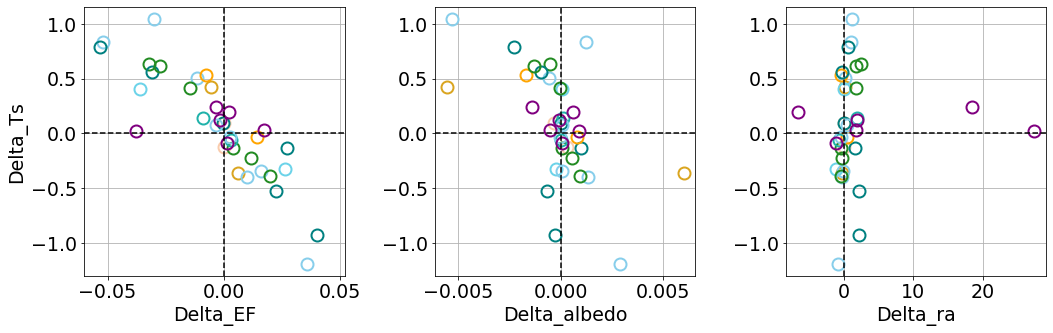

In [17]:
plt.rcParams.update({'font.size': 19})
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
for i,text in enumerate(crosswalk.description):
    plt.plot(delta_EF_global[i],delta_Ts_global[i],
             'o',fillstyle='none',color=colors[i],markersize=12,
            markeredgewidth=2)
plt.grid()
plt.axhline(y=0,linestyle='--',color='k')
plt.axvline(x=0,linestyle='--',color='k')
plt.xlim([-0.06,0.052])
plt.xlabel('Delta_EF')
plt.ylabel('Delta_Ts')

plt.subplot(1,3,2)
for i,text in enumerate(crosswalk.description):
    plt.plot(delta_albedo_global[i],delta_Ts_global[i],
             'o',fillstyle='none',color=colors[i],markersize=12,
            markeredgewidth=2)
plt.grid()
plt.axhline(y=0,linestyle='--',color='k')
plt.axvline(x=0,linestyle='--',color='k')
plt.xlabel('Delta_albedo')
#plt.ylabel('Delta_Ts')

plt.subplot(1,3,3)
for i,text in enumerate(crosswalk.description):
    plt.plot(delta_ra_global[i],delta_Ts_global[i],
             'o',fillstyle='none',color=colors[i],markersize=12,
            markeredgewidth=2)
plt.grid()
plt.axhline(y=0,linestyle='--',color='k')
plt.axvline(x=0,linestyle='--',color='k')
plt.xlabel('Delta_ra')
#plt.ylabel('Delta_Ts')

plt.tight_layout()
#plt.savefig('../Figures/global_average_mechanism.pdf')

### Linear regression for global average

In [18]:
var1=delta_EF_global
var2=delta_albedo_global
var3=delta_ra_global
yvar=delta_Ts_global

var1_name='EF'
var2_name='albedo'
var3_name='ra'

X_all = np.transpose(np.array([var1, var2,    var3]))
X_butvar1 = np.transpose(np.array([var2,    var3]))
X_butvar2 = np.transpose(np.array([var1,    var3]))
X_butvar3 = np.transpose(np.array([var1, var2]))
y = yvar

reg = LinearRegression()


reg.fit(X_all, y) # Fit the model to the data
R2_all=(reg.score(X_all, y)) # Save R2

reg.fit(X_butvar1, y) # Fit the model to the data
R2_butvar1=(reg.score(X_butvar1, y)) # Save R2

reg.fit(X_butvar2, y) # Fit the model to the data
R2_butvar2=(reg.score(X_butvar2, y)) # Save R2

reg.fit(X_butvar3, y) # Fit the model to the data
R2_butvar3=(reg.score(X_butvar3, y)) # Save R2

In [19]:
R2_EF_global = R2_all - R2_butvar1
R2_albedo_global=R2_all - R2_butvar2
R2_ra_global=R2_all - R2_butvar3
R2_interactions_global = R2_all - (R2_EF_global+R2_albedo_global+R2_ra_global)
R2_all_global=R2_all
print(R2_EF_global*100)
print(R2_albedo_global*100)
print(R2_ra_global*100)
print(R2_all_global*100)

53.34116721650059
8.918540220241766
2.2680283495449927
85.11339122650351


In [20]:
R2_EF_global = R2_all - R2_butvar1
R2_albedo_global=R2_all - R2_butvar2
R2_ra_global=R2_all - R2_butvar3
R2_interactions_global = R2_all - (R2_EF_global+R2_albedo_global+R2_ra_global)
R2_all_global=R2_all

sigdigits=5
print(np.round(R2_EF_global*100,sigdigits))
print(np.round(R2_albedo_global*100,sigdigits))
print(np.round(R2_ra_global*100,sigdigits))
print(np.round(R2_all_global*100,sigdigits))

53.34117
8.91854
2.26803
85.11339


# Process data

### Calculate new quantities

In [21]:
# Albedo
albedo_offline=da_FSR_offline/da_FSDS_offline
albedo_ref_offline=(FSR_offline_ref/FSDS_offline_ref)

# Evaporative fraction
EF_offline_ref=LH_offline_ref/(LH_offline_ref+SH_offline_ref)
da_EF_offline=da_LH_offline/(da_LH_offline+da_SH_offline)

In [22]:
# Changes from reference case
delta_albedo_offline=albedo_offline-albedo_ref_offline

delta_Ts_offline=da_Ts_offline-Ts_offline_ref
delta_Ts_coupled=da_Ts_coupled-Ts_coupled_ref

delta_EF_offline=da_EF_offline-EF_offline_ref

# Multiple linear regression at each point

### Define variables to use in regression

In [37]:
var1=delta_EF_offline
var2=delta_albedo_offline
var3=deltas_ra_offline
#yvar=delta_Ts_coupled
yvar=PRECT['calculated_PREC_FROM_ATM']

var1_name='EF'
var2_name='albedo'
var3_name='ra'

In [38]:
var1=var1.where(~(np.isnan(var1)&~np.isnan(landfrac)),0)
var3=var3.where(~(np.isnan(var3)&~np.isnan(landfrac)),0)

### Check correlation between variables

In [39]:
# Make empty arrays for regression output
x1andx2=np.zeros(np.shape(delta_EF_offline[:,:,0]))
x1andx2[:]=np.nan

x1andx3=np.zeros(np.shape(delta_EF_offline[:,:,0]))
x1andx3[:]=np.nan

x2andx3=np.zeros(np.shape(delta_EF_offline[:,:,0]))
x2andx3[:]=np.nan

x1andY=np.zeros(np.shape(delta_EF_offline[:,:,0]))
x1andY[:]=np.nan

x2andY=np.zeros(np.shape(delta_EF_offline[:,:,0]))
x2andY[:]=np.nan

x3andY=np.zeros(np.shape(delta_EF_offline[:,:,0]))
x3andY[:]=np.nan

In [40]:
for i in np.arange(0,96):
    for j in np.arange(0,144):
        if ~np.isnan(landfrac[i,j].values):
            x1andx2[i,j]=np.corrcoef(var1[i,j,:],var2[i,j,:])[0,1]
            x1andx3[i,j]=np.corrcoef(var1[i,j,:],var3[i,j,:])[0,1]
            x2andx3[i,j]=np.corrcoef(var2[i,j,:],var3[i,j,:])[0,1]
            x1andY[i,j]=np.corrcoef(var1[i,j,:],yvar[i,j,:])[0,1]
            x2andY[i,j]=np.corrcoef(var2[i,j,:],yvar[i,j,:])[0,1]
            x3andY[i,j]=np.corrcoef(var3[i,j,:],yvar[i,j,:])[0,1]

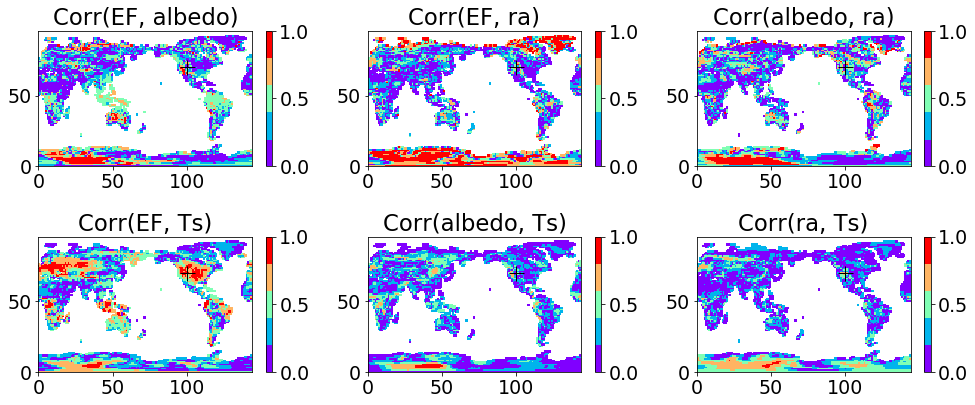

In [41]:
vmin=0
vmax=1
i=70
j=100
cmap=plt.cm.get_cmap("rainbow",5)

plt.figure(figsize=(14,6))
plt.subplot(2,3,1)
plt.pcolormesh(np.abs(x1andx2),cmap=cmap,vmin=vmin, vmax=vmax)
plt.plot(j,i,'+k',markersize=15)
plt.title('Corr('+var1_name+', '+var2_name+')')
plt.colorbar()
plt.subplot(2,3,2)
plt.pcolormesh(np.abs(x1andx3),cmap=cmap,vmin=vmin, vmax=vmax)
plt.title('Corr('+var1_name+', '+var3_name+')')
plt.plot(j,i,'+k',markersize=15)
plt.colorbar()
plt.subplot(2,3,3)
plt.pcolormesh(np.abs(x2andx3),cmap=cmap,vmin=vmin, vmax=vmax)
plt.title('Corr('+var2_name+', '+var3_name+')')
plt.plot(j,i,'+k',markersize=15)
plt.colorbar()
plt.subplot(2,3,4)
plt.pcolormesh(np.abs(x1andY),cmap=cmap,vmin=vmin, vmax=vmax)
plt.title('Corr('+var1_name+', '+'Ts'+')')
plt.plot(j,i,'+k',markersize=15)
plt.colorbar()
plt.subplot(2,3,5)
plt.pcolormesh(np.abs(x2andY),cmap=cmap,vmin=vmin, vmax=vmax)
plt.title('Corr('+var2_name+', '+'Ts'+')')
plt.plot(j,i,'+k',markersize=15)
plt.colorbar()
plt.subplot(2,3,6)
plt.pcolormesh(np.abs(x3andY),cmap=cmap,vmin=vmin, vmax=vmax)
plt.title('Corr('+var3_name+', '+'Ts'+')')
plt.plot(j,i,'+k',markersize=15)
plt.colorbar()

plt.tight_layout()

### Do regression

In [42]:
# Make empty arrays for regression output
R2s_allbut1=np.zeros(np.shape(delta_EF_offline[:,:,0]))
R2s_allbut1[:]=np.nan
R2s_allbut2=np.zeros(np.shape(delta_EF_offline[:,:,0]))
R2s_allbut2[:]=np.nan
R2s_allbut3=np.zeros(np.shape(delta_EF_offline[:,:,0]))
R2s_allbut3[:]=np.nan
R2s_all=np.zeros(np.shape(delta_EF_offline[:,:,0]))
R2s_all[:]=np.nan

In [43]:
### ALL BUT VAR 1
for i in np.arange(0,96):
    print(i)
    for j in np.arange(0,144):
        if ~np.isnan(landfrac[i,j].values):
            
            # Define multiple predictors and one predictant
            X = np.transpose(np.array([
                var2[i,j,:],
                               var3[i,j,:]
                              ]))
            y = yvar[i,j,:]

            # Create an instance of the LinearRegression class
            reg = LinearRegression()

            # Fit the model to the data
            reg.fit(X, y)

            # Save R2
            R2=(reg.score(X, y))
            R2s_allbut1[i,j]=R2

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95


In [44]:
### ALL BUT VAR 2
for i in np.arange(0,96):
    print(i)
    for j in np.arange(0,144):
        if ~np.isnan(landfrac[i,j].values):
            
            # Define multiple predictors and one predictant
            X = np.transpose(np.array([
                var1[i,j,:],
                               var3[i,j,:]
                              ]))
            y = yvar[i,j,:]

            # Create an instance of the LinearRegression class
            reg = LinearRegression()

            # Fit the model to the data
            reg.fit(X, y)

            # Save R2
            R2=(reg.score(X, y))
            R2s_allbut2[i,j]=R2

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95


In [45]:
### ALL BUT VAR 3
for i in np.arange(0,96):
    print(i)
    for j in np.arange(0,144):
        if ~np.isnan(landfrac[i,j].values):
            
            # Define multiple predictors and one predictant
            X = np.transpose(np.array([
                var1[i,j,:],
                               var2[i,j,:]
                              ]))
            y = yvar[i,j,:]

            # Create an instance of the LinearRegression class
            reg = LinearRegression()

            # Fit the model to the data
            reg.fit(X, y)

            # Save R2
            R2=(reg.score(X, y))
            R2s_allbut3[i,j]=R2

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95


In [46]:
### ALL
for i in np.arange(0,96):
    print(i)
    for j in np.arange(0,144):
        if ~np.isnan(landfrac[i,j].values):
            
            # Define multiple predictors and one predictant
            X = np.transpose(np.array([
                var1[i,j,:],
                var2[i,j,:],
                               var3[i,j,:]
                              ]))
            y = yvar[i,j,:]

            # Create an instance of the LinearRegression class
            reg = LinearRegression()

            # Fit the model to the data
            reg.fit(X, y)

            # Save R2
            R2=(reg.score(X, y))
            R2s_all[i,j]=R2

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95


In [47]:
R2s_all_xr=xr.DataArray(R2s_all,
            dims=("lat", "lon"),
    coords=[('lat',delta_EF_offline.lat),
            ('lon',delta_EF_offline.lon)])
R2s_allbut1_xr=xr.DataArray(R2s_allbut1,
            dims=("lat", "lon"),
    coords=[('lat',delta_EF_offline.lat),
            ('lon',delta_EF_offline.lon)])
R2s_allbut2_xr=xr.DataArray(R2s_allbut2,
            dims=("lat", "lon"),
    coords=[('lat',delta_EF_offline.lat),
            ('lon',delta_EF_offline.lon)])
R2s_allbut3_xr=xr.DataArray(R2s_allbut3,
            dims=("lat", "lon"),
    coords=[('lat',delta_EF_offline.lat),
            ('lon',delta_EF_offline.lon)])

In [48]:
R2_EF_gridcell = R2s_all_xr - R2s_allbut1_xr
R2_albedo_gridcell=R2s_all_xr - R2s_allbut2_xr
R2_ra_gridcell=R2s_all_xr - R2s_allbut3_xr
R2_interactions_gridcell = R2s_all_xr - (R2_EF_gridcell+
                                         R2_albedo_gridcell+
                                         R2_ra_gridcell)
R2s_all_gridcell=R2s_all_xr

In [50]:
sigdigits=5
print(np.round((R2_EF_gridcell*landweights).mean(dim=['lat','lon']).values*100,sigdigits))
print(np.round((R2_albedo_gridcell*landweights).mean(dim=['lat','lon']).values*100,sigdigits))
print(np.round((R2_ra_gridcell*landweights).mean(dim=['lat','lon']).values*100,sigdigits))
print(np.round((R2_interactions_gridcell*landweights).mean(dim=['lat','lon']).values*100,sigdigits))
print(np.round((R2s_all_gridcell*landweights).mean(dim=['lat','lon']).values*100,sigdigits))

19.56668
5.83925
4.31025
5.66327
35.37945
